# Inferência Bayesiana com MCMC na Refratometria de Gases

Este notebook tem como objetivo apresentar a classe `MCMCInference` e demonstrar como o método de Monte Carlo via Cadeias de Markov (MCMC) é aplicado para analisar o problema físico da refratometria de gases.

## O Problema Físico e a Inferência Bayesiana
Na refratometria gasosa, o problema inverso consiste em descobrir as frações molares dos gases que compõem uma mistura a partir de medições experimentais da refratividade da luz. Contudo, devido a semelhanças nas propriedades dos gases e da possível dependência (colinearidade) entre os vetores da matriz de refratividade, refletida pelo alto número de condição $\kappa$, o sistema linear gerado torna-se muitas vezes **mal condicionado**. Isso significa que pequenos ruídos experimentais podem causar enormes incertezas na predição de cada fração molar.

Para contornar isso, empregamos a **Inferência Bayesiana**. Ao invés de buscar uma única resposta exata (que seria extremamente suscetível a esses desvios numéricos), buscamos uma **distribuição de probabilidade posterior** das concentrações (vetor $\phi$), condicionados aos resultados experimentais obtidos (vetor observado $b_{obs}$) e às restrições fundamentais do sistema.

Pelo Teorema de Bayes, temos a relação:
$$ p(\phi|b_{obs}) \propto p(b_{obs}|\phi) \cdot p(\phi) $$

Onde:
- $p(\phi)$ é a probabilidade **Prior**: Representa nosso conhecimento ou restrição prévia do sistema. Na nossa aplicação física, nós sabemos que as frações molares não podem ser negativas e também não podem ser maiores do que 1 ($0 \le x_i \le 1$). Ademais, a restrição de linearidade nos diz que as concentrações devem somar 1. Usamos a função *prior* para descartar todas as soluções impossíveis (fisicamente irreais).
- $p(b_{obs}|\phi)$ é o **Likelihood** (Função de Verossimilhança): Reflete o quão os dados $b_{obs}$ observados produzem a refratividade teórica testada por $\phi$. Assumindo uma distribuição gaussiana dos erros ($\sigma$), isso é ditado por uma minimização do Qui-quadrado ($\chi^2$) entre a medição teórica e a teórica que temos em mãos.

## Implementação com MCMC e `emcee`
O algoritmo MCMC explora todo esse cenário utilizando múltiplos "caminhantes" (*walkers*). Ao invés de resolver analiticamente a equação, ele amostra sistematicamente o espaço da função probabilidade. Ele testa vetores e avança de forma aleatória nas direções das melhores respostas, convergindo para a região de alta densidade provável.

Abaixo, importamos as funções do módulo `gasopt` e preparamos nosso ambiente de inferência.

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt

try:
    import gasopt
except:
    import sys
    sys.path.append('..')
    import gasopt

from gasopt.bayes_inference import MCMCInference, plot_trace, plot_distribution
from gasopt.gladstone_dale import GasMix
from gasopt.dispersion import Gas
from gasopt.plotting import add_text_panel

### Configurando o Experimento
Nós definimos os gases a serem analisados, determinamos a bateria de medições em comprimentos de onda específicos e construímos a matriz refrativa a partir da classe auxiliar `GasMix`.

In [ ]:
# Constantes experimentais e Gases envolvidos
GASESID = ['co2_1', 'o2', 'n2_1', 'ar_1']
LAMBDAS = [0.74, 0.78, 0.82, 0.86] # Espectro 

# Inicializando a Matriz de refratividades
gases = [gasopt.Gas(id=g) for g in GASESID]
operador = gasopt.GasMix(gases=gases, wvlens=LAMBDAS, temp=273.15)
mtx = operador.get_matrix()
sigma_mtx = operador.get_sigma_matrix()
kappa = mtx.cond_number()
print("Matriz de Refratividades:\n", mtx)
print(f'Numero de condição: {np.linalg.cond(mtx)}')
print(f'Numero de condição: {kappa}')


# Simulando as frações molares para testar a nossa inferência
x_real = [0.2, 0.3, 0.4, 0.1]

Matriz de Refratividades:
 [[ 4.91664495e-04  6.87331907e-05  9.90513272e-04 -1.29058966e-03]
 [ 4.89873731e-04  3.16770068e-04  3.24917119e-04  3.11630986e-04]
 [ 4.43539990e-04  2.67664673e-04  2.96072745e-04  2.79547810e-04]
 [ 4.40186832e-04  2.64772677e-04  2.93823010e-04  2.77208508e-04]]
Numero de condição: 25263.15383756779
Numero de condição: 25263.15383756779


### Inicializando a Inferência Bayesiana
Vamos invocar a nossa classe `MCMCInference`. O método `run_mcmc` dessa classe já organiza uma posição inicial razoável (fisicamente aceita pela nossa restrição *Prior*) para todos os nossos $N$ *walkers* e em seguida solicita ao motor numérico `emcee` que realize a amostragem em milhares de passos de iterações contínuas.

Nesse teste, instruímos a classe com o vetor molar limpo (real). Internamente ela vai gerar os resultados de refratividade teóricos e perturbar os mesmos com um ruído percentual (Erro Experimental) que estipulamos em $0.1\%$ ($0.001$).

In [ ]:
ERRO_EXP = 0.00001 # 0.1% de ruído da medição física
KAPPA = np.linalg.cond(mtx)
print(f"O Número de Condição da Matriz (Kappa) é: {KAPPA:.2e}")

# Instanciando o objeto que toma conta de todos os parâmetros estocásticos e simula o b_obs ruidoso:
inferencia = MCMCInference(mtx=mtx, sigma_mtx=sigma_mtx, phi_real=x_real, erro=ERRO_EXP)

# Executa os walkers pelo espaço em busca da cadeia posterior de probabilidade
print("Iniciando MCMC com emcee...")
sampler = inferencia.run_mcmc(n_walkers=10, n_steps=7500, progress=True)

# Extraímos a cadeia e também a sua versão \"achatada\". 
# Aplicamos um Burn-in de 300 (descartando os 300 passos iniciais para garantir que só leremos após o sistema convergir)
chain, chainflat = inferencia.get_results(burn_in=300)

O Número de Condição da Matriz (Kappa) é: 2.53e+04
Iniciando MCMC com emcee...


100%|██████████| 7500/7500 [00:03<00:00, 2456.25it/s]


### Plotagem e Resultados
Para verificar não apenas os valores nominais mas sim as incertezas estimadas pelo teorema de Bayes e atestar o quão contido o nosso erro está para os gases que foram procurados, fazemos a apresentação do "Trace" das cadeias, e por fim uma visualização em Histograma revelando o quão longe os desvios padrões ficaram do eixo do vetor analítico real.

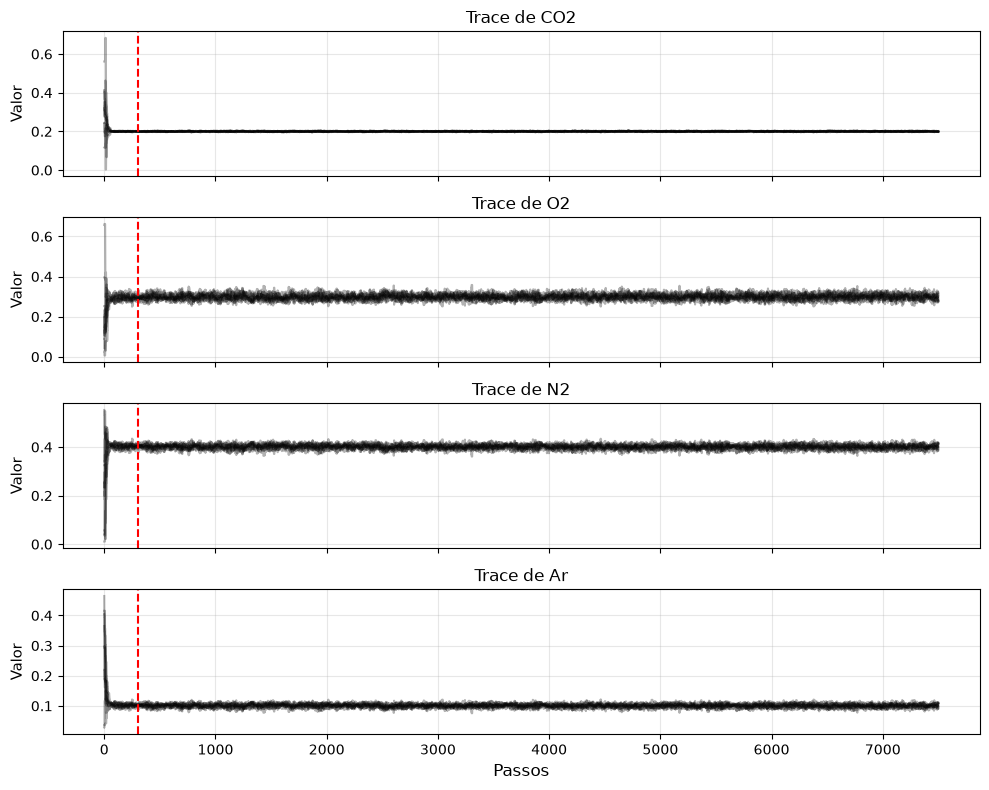

In [44]:
# Rótulos identificadores das variáveis (omitindo o índice removido)
labels = [gasopt.Gas(i).name for i in GASESID]

# 1. Plotando as cadeias dos walkers para averiguação da convergência estável em um limite numérico
img_trace = plot_trace(chain, burn_in=300, labels=labels)

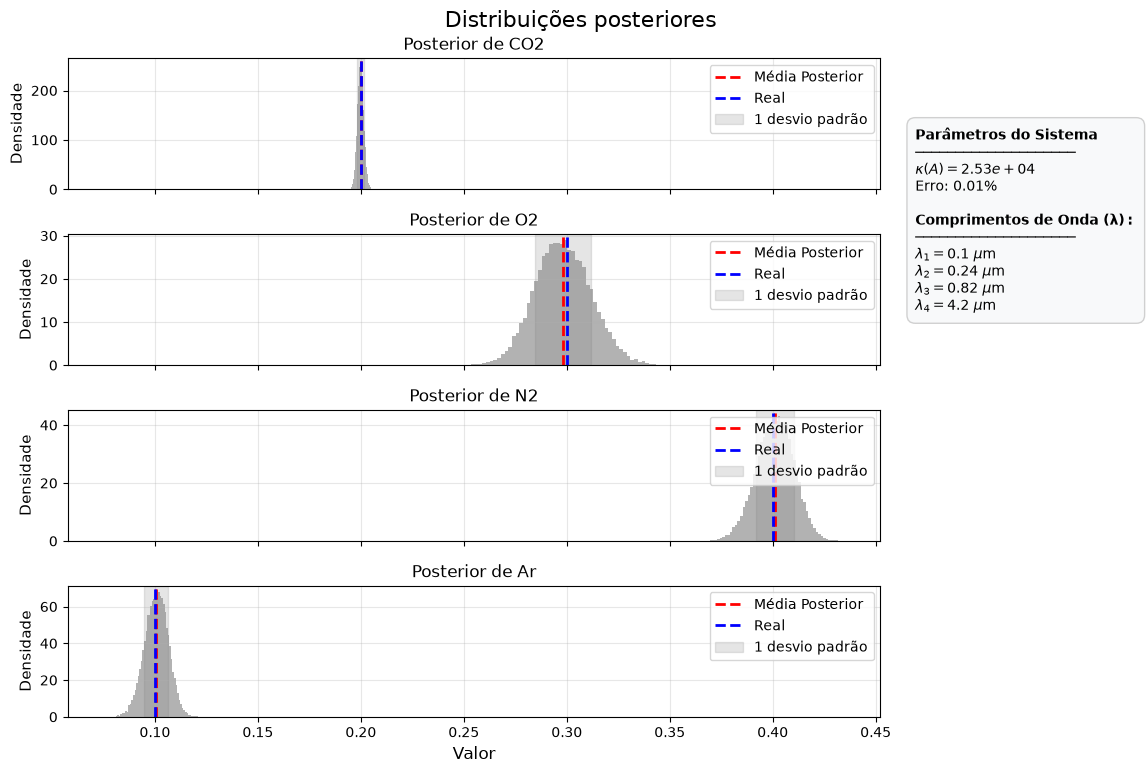

In [45]:
# 2. Plotando a distribuição da Solução Bayesiana Final
titulo = rf'Distribuições posteriores'
img_dist = plot_distribution(chainflat, x_real=x_real, titulo=titulo, labels=labels)
add_text_panel(
    fig=img_dist,
    lambdas=LAMBDAS,
    cond_num=kappa,
    erro=ERRO_EXP
)
